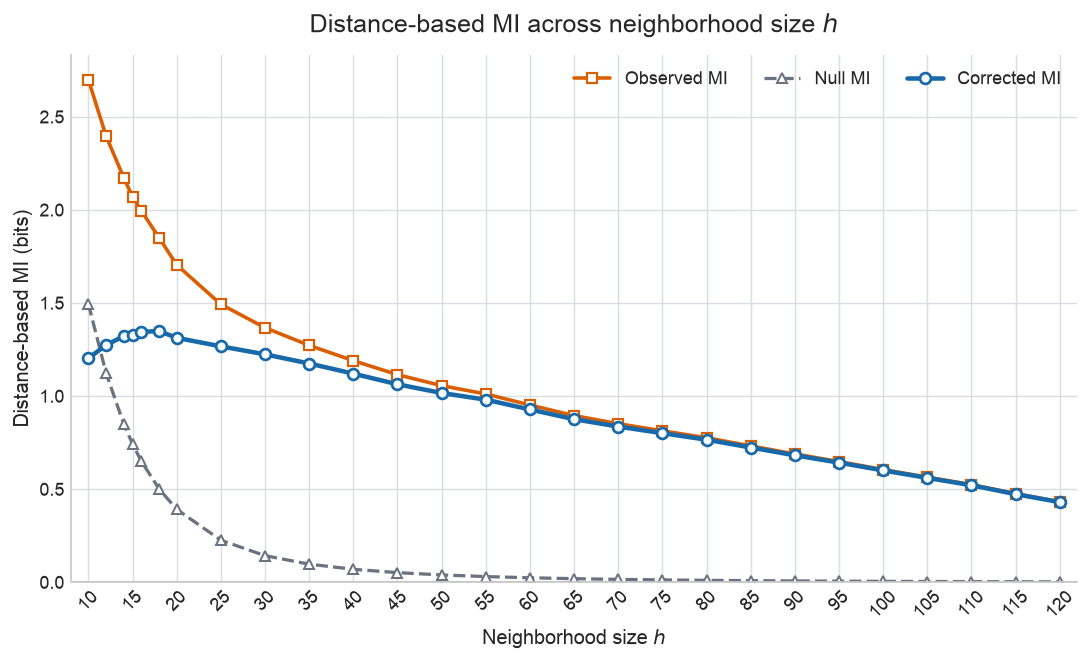

In [ ]:
import csv
from pathlib import Path


import matplotlib.pyplot as plt


h_sweep_path = Path('output/figures/mi_h_sweep_10s_0825_results.csv')


with h_sweep_path.open(newline='') as f:
    rows = list(csv.DictReader(f))




h_sweep = sorted(
    (
        int(row['distance_based_mi_h']),
        float(row['distance_based_mi']),
        float(row['distance_based_mi_null']),
        float(row['distance_based_mi_corrected']),
    )
    for row in rows
)




h_values, observed_mi, null_mi, corrected_mi = zip(*h_sweep)




plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8.5, 5.2), dpi=130)




ax.plot(
    h_values,
    observed_mi,
    color='#d95f02',
    linewidth=2.0,
    marker='s',
    markersize=5.5,
    markerfacecolor='white',
    markeredgewidth=1.2,
    label='Observed MI',
)
ax.plot(
    h_values,
    null_mi,
    color='#6b7280',
    linewidth=1.8,
    linestyle='--',
    marker='^',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.1,
    label='Null MI',
)
ax.plot(
    h_values,
    corrected_mi,
    color='#1769aa',
    linewidth=2.5,
    marker='o',
    markersize=6,
    markerfacecolor='#f7fbff',
    markeredgecolor='#1769aa',
    markeredgewidth=1.5,
    label='Corrected MI',
)




ax.axhline(0, color='#374151', linewidth=1, alpha=0.65)
ax.set_title(r'Distance-based MI across neighborhood size $h$', fontsize=14, pad=12)
ax.set_xlabel(r'Neighborhood size $h$', fontsize=11)
ax.set_ylabel('Distance-based MI (bits)', fontsize=11)
tick_start = ((min(h_values) + 4) // 5) * 5
tick_end = (max(h_values) // 5) * 5
ax.set_xticks(range(tick_start, tick_end + 1, 5))
ax.tick_params(axis='x', rotation=45)
ax.set_xlim(min(h_values) - 2, max(h_values) + 2)
ax.set_ylim(bottom=min(0, min(null_mi), min(corrected_mi)) * 1.05)
ax.grid(True, color='#d9dee5', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='best', ncols=3)




fig.tight_layout()
figure_path = Path('output/figures/mi_h_sweep_comparison.png')
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

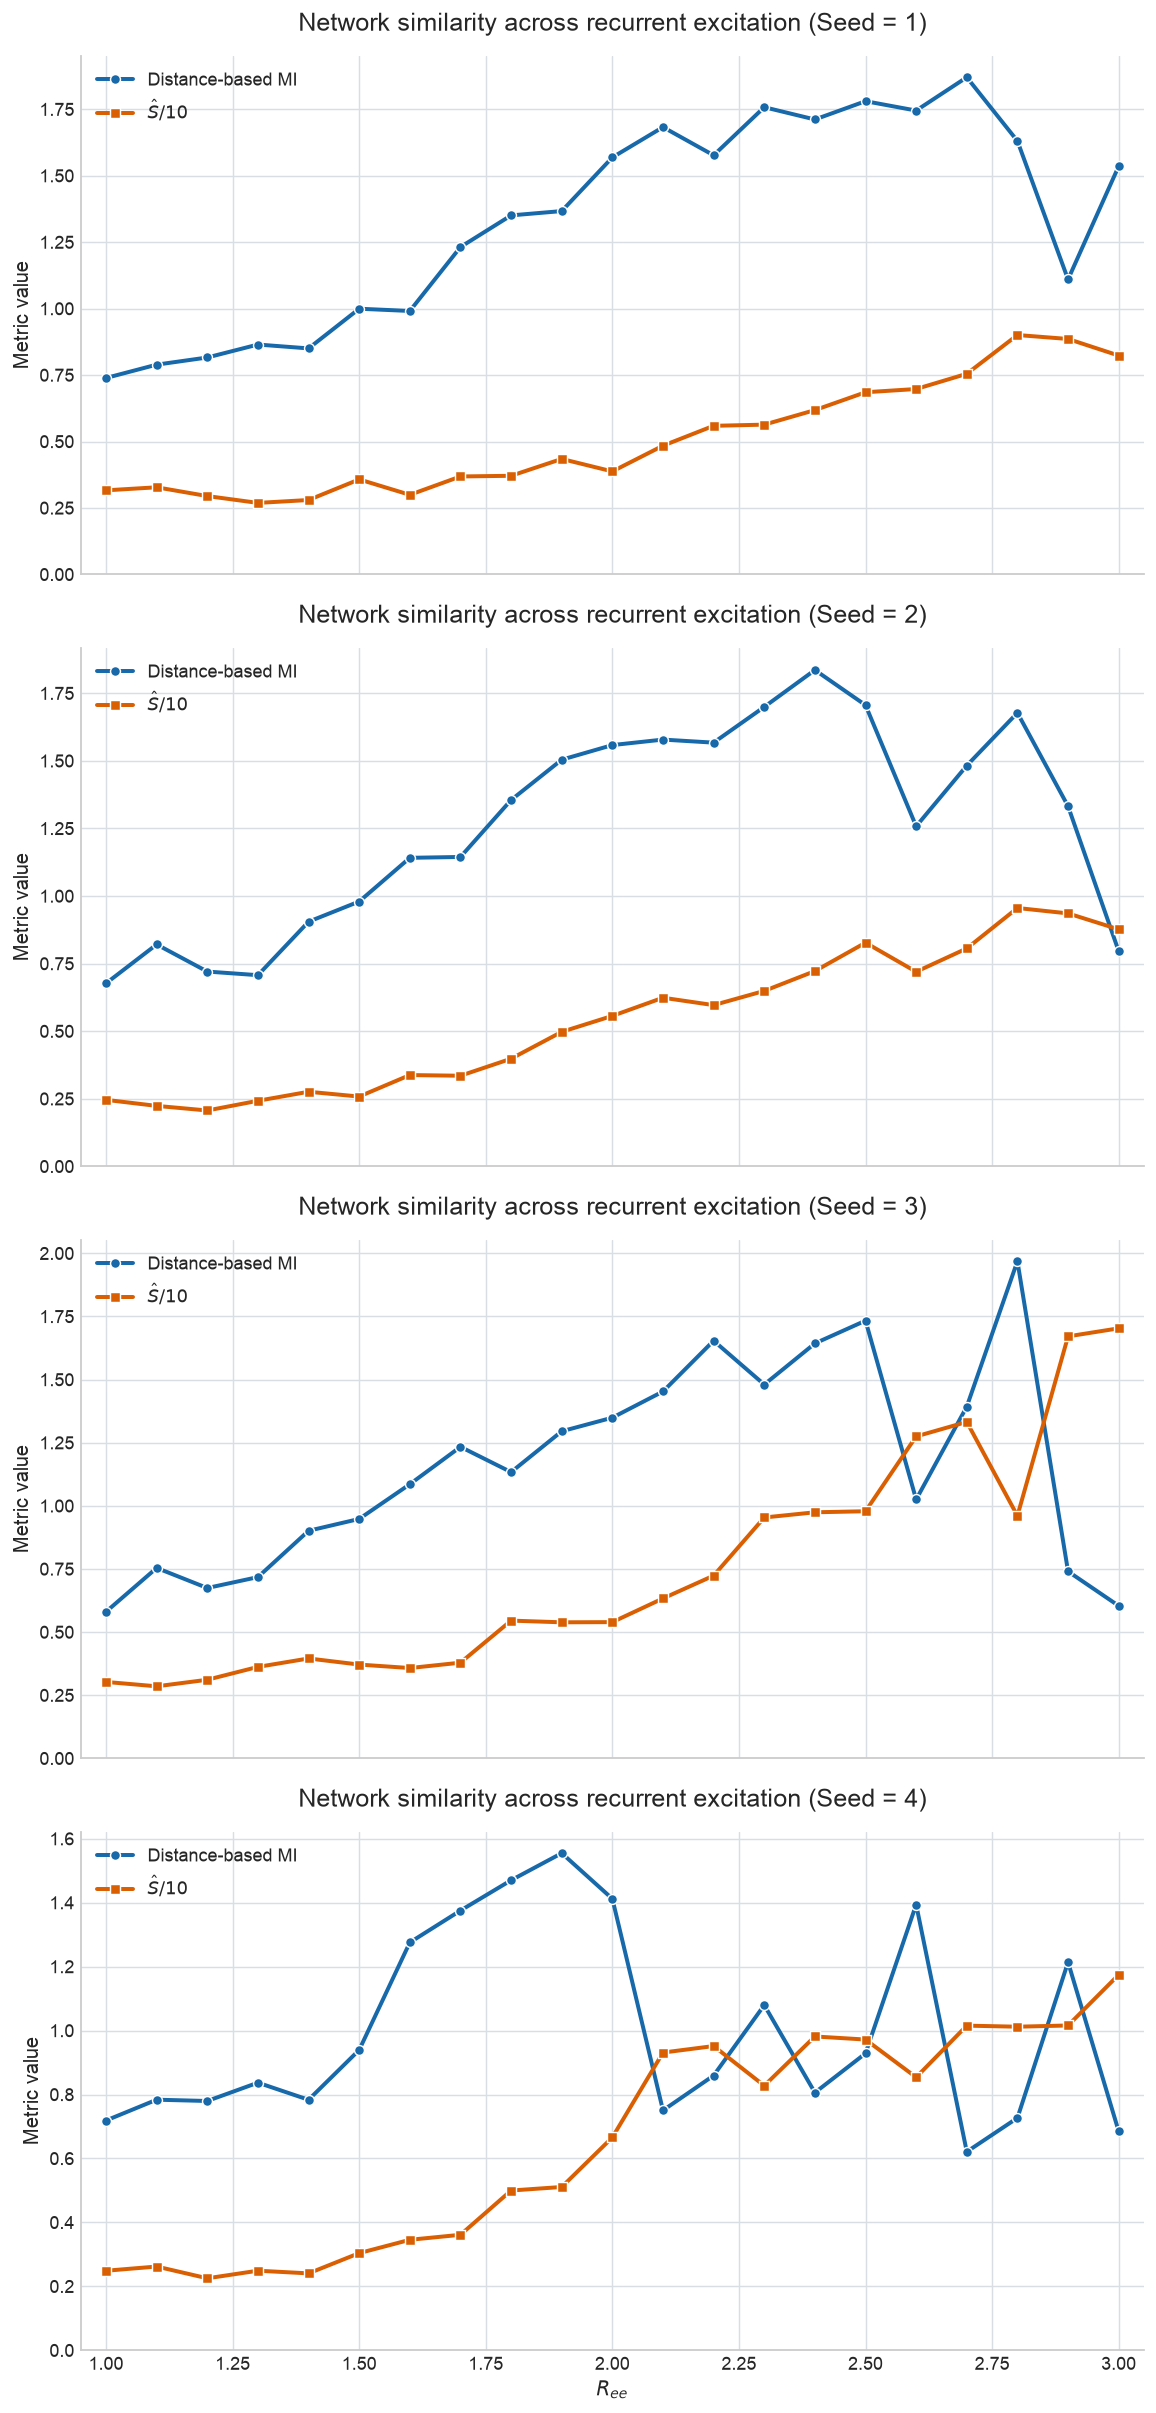

In [ ]:
import csv
from pathlib import Path




import matplotlib.pyplot as plt




csv_paths = [
    Path('output/figures/10s_experiments/2_uniform/h18/mi_r_ee_sweep_seed_1_10s_results.csv'),
    Path('output/figures/10s_experiments/2_uniform/h18/mi_r_ee_sweep_seed_2_10s_results.csv'),
    Path('output/figures/10s_experiments/2_uniform/h18/mi_r_ee_sweep_seed_3_10s_results.csv'),
    Path('output/figures/10s_experiments/2_uniform/h18/mi_r_ee_sweep_seed_4_10s_results.csv'),
]




plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(nrows=len(csv_paths), ncols=1, figsize=(9, (14 / 3) * len(csv_paths)), dpi=130, sharex=True)




for idx, (ax, csv_path) in enumerate(zip(axes, csv_paths), start=1):
    with csv_path.open(newline='') as f:
        rows = list(csv.DictReader(f, delimiter=','))




    data = {
        column: [row[column] for row in rows]
        for column in rows[0]
    }




    r_ee = [float(value) for value in data['R_ee']]
    distance_mi = [float(value) for value in data['distance_based_mi_corrected']]
    s_hat = [float(value) for value in data['s_hat']]
    null_distance_mi = [float(value) for value in data['distance_based_mi_null']]




    # Connect points in R_ee order regardless of row order in the CSV.
    sort_order = sorted(range(len(r_ee)), key=lambda row_idx: r_ee[row_idx])
    r_ee = [r_ee[row_idx] for row_idx in sort_order]
    distance_mi = [distance_mi[row_idx] for row_idx in sort_order]
    s_hat = [s_hat[row_idx] for row_idx in sort_order]
    null_distance_mi = [null_distance_mi[row_idx] for row_idx in sort_order]




    ax.plot(
        r_ee,
        distance_mi,
        color='#1769aa',
        linewidth=2.2,
        marker='o',
        markersize=5.5,
        markeredgecolor='white',
        markeredgewidth=0.8,
        label='Distance-based MI',
    )
    ax.plot(
        r_ee,
        [value / 10 for value in s_hat],
        color='#d95f02',
        linewidth=2.2,
        marker='s',
        markersize=5.2,
        markeredgecolor='white',
        markeredgewidth=0.8,
        label='$\\hat{S} / 10$',
    )




    ax.set_title(f'Network similarity across recurrent excitation (Seed = {idx})', fontsize=14, pad=14)
    ax.set_ylabel('Metric value', fontsize=11)
    ax.set_xlim(min(r_ee) - 0.05, max(r_ee) + 0.05)
    ax.set_ylim(bottom=0)
    ax.grid(True, color='#d9dee5', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')




axes[-1].set_xlabel('$R_{ee}$', fontsize=11)
fig.tight_layout()
plt.savefig('mi_r_ee_sweep_2_uniform_summary_results.png', dpi=300, bbox_inches='tight')

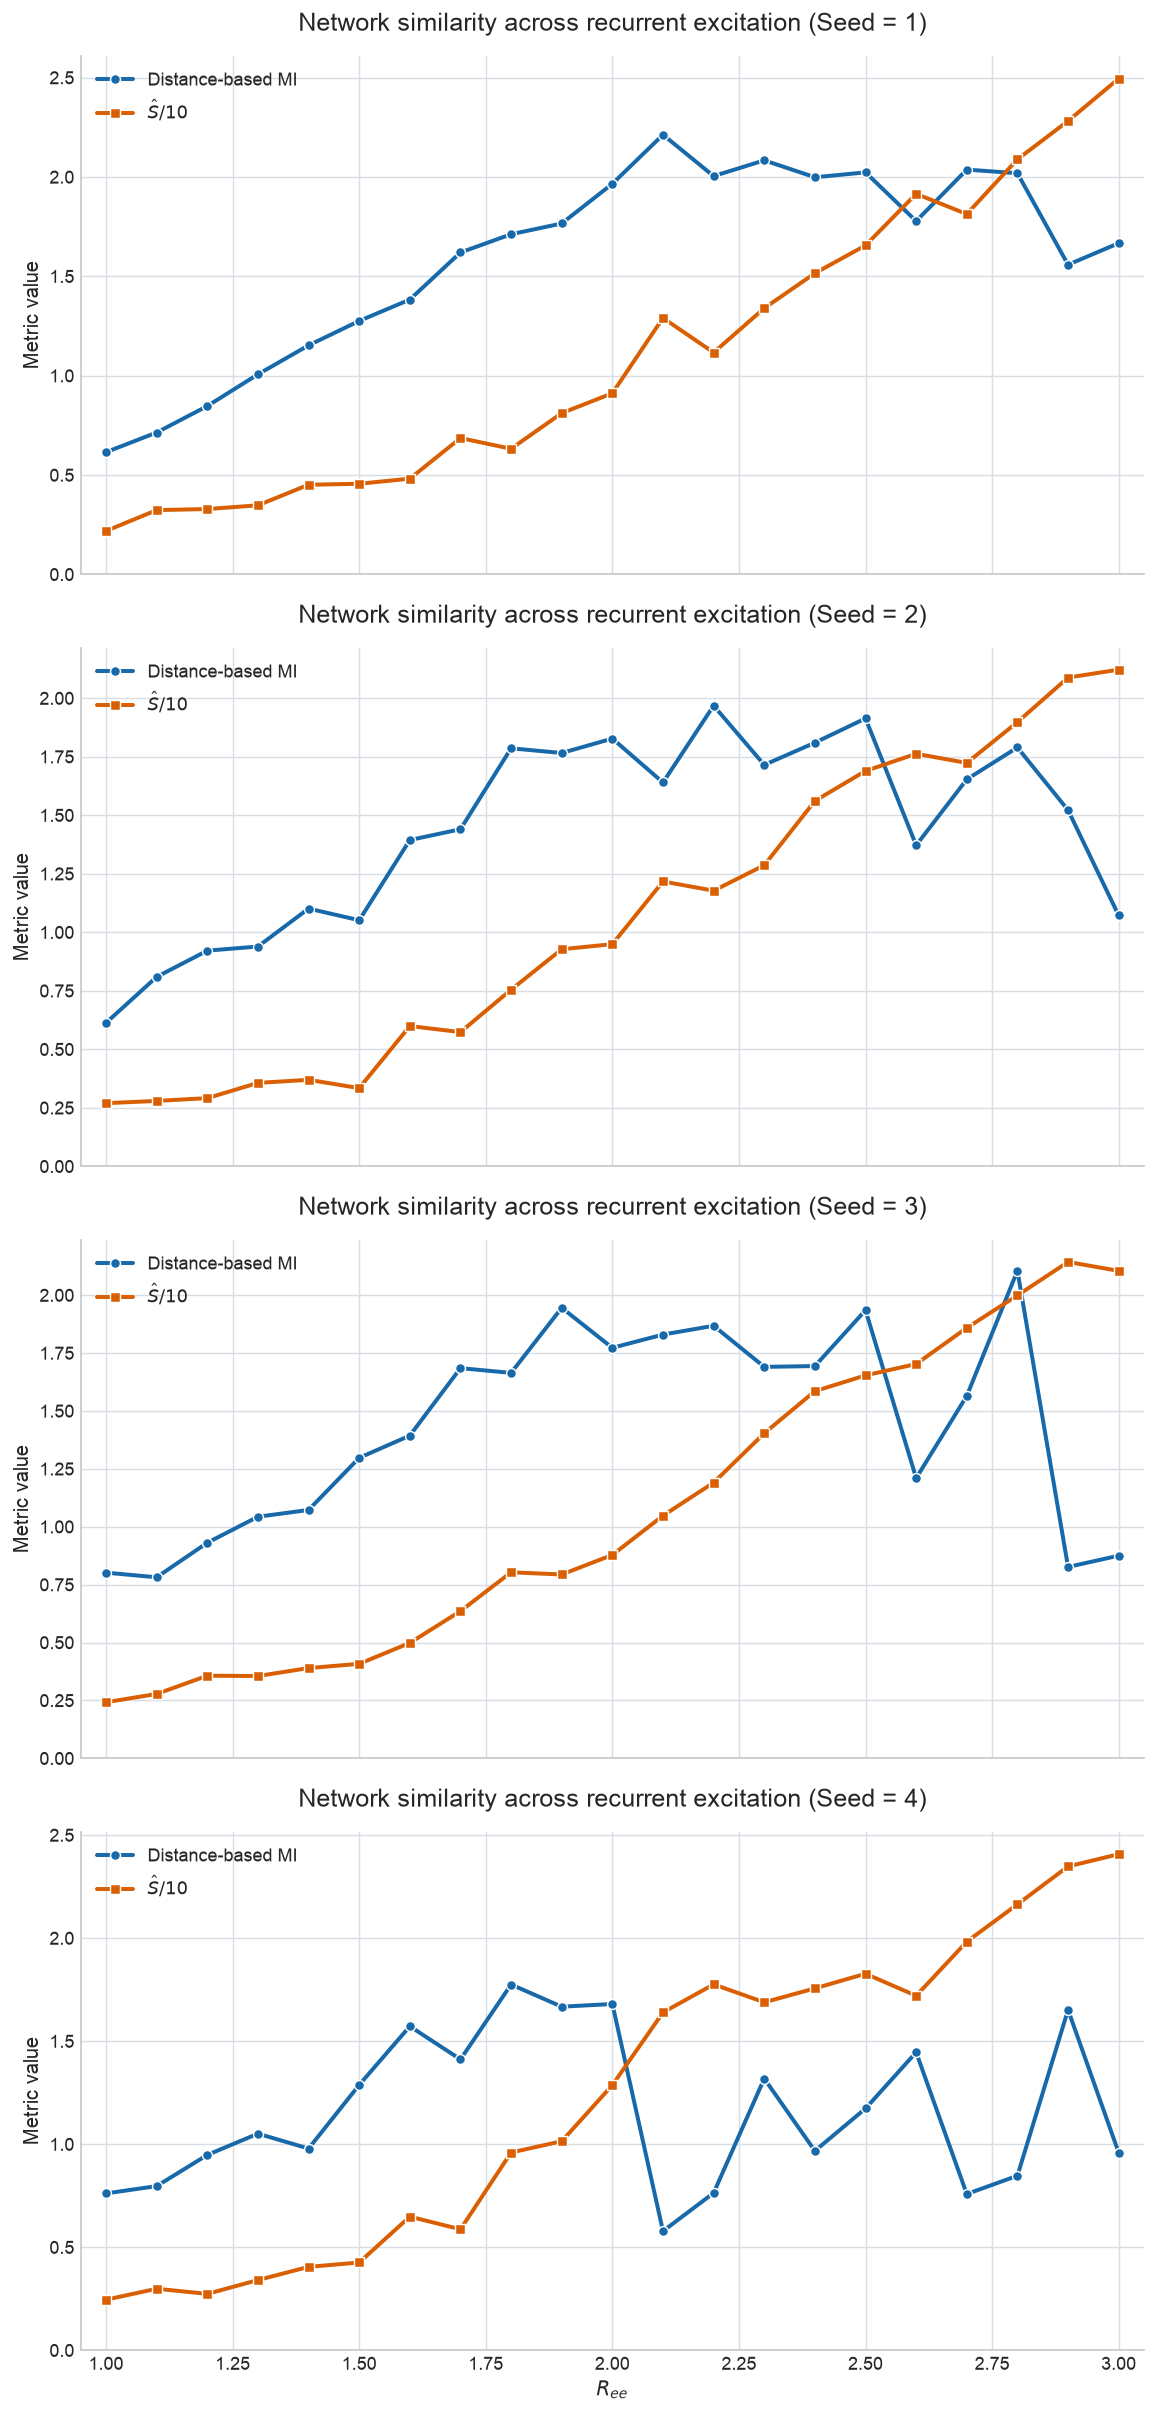

In [ ]:
import csv
from pathlib import Path




import matplotlib.pyplot as plt




csv_paths = [
    Path('output/figures/10s_experiments/1_uniform/h18/mi_r_ee_sweep_seed_1_10s_results.csv'),
    Path('output/figures/10s_experiments/1_uniform/h18/mi_r_ee_sweep_seed_2_10s_results.csv'),
    Path('output/figures/10s_experiments/1_uniform/h18/mi_r_ee_sweep_seed_3_10s_results.csv'),
    Path('output/figures/10s_experiments/1_uniform/h18/mi_r_ee_sweep_seed_4_10s_results.csv'),
]




plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(nrows=len(csv_paths), ncols=1, figsize=(9, (14 / 3) * len(csv_paths)), dpi=130, sharex=True)




for idx, (ax, csv_path) in enumerate(zip(axes, csv_paths), start=1):
    with csv_path.open(newline='') as f:
        rows = list(csv.DictReader(f, delimiter=','))




    data = {
        column: [row[column] for row in rows]
        for column in rows[0]
    }




    r_ee = [float(value) for value in data['R_ee']]
    distance_mi = [float(value) for value in data['distance_based_mi_corrected']]
    s_hat = [float(value) for value in data['s_hat']]
    null_distance_mi = [float(value) for value in data['distance_based_mi_null']]




    # Connect points in R_ee order regardless of row order in the CSV.
    sort_order = sorted(range(len(r_ee)), key=lambda row_idx: r_ee[row_idx])
    r_ee = [r_ee[row_idx] for row_idx in sort_order]
    distance_mi = [distance_mi[row_idx] for row_idx in sort_order]
    s_hat = [s_hat[row_idx] for row_idx in sort_order]
    null_distance_mi = [null_distance_mi[row_idx] for row_idx in sort_order]




    ax.plot(
        r_ee,
        distance_mi,
        color='#1769aa',
        linewidth=2.2,
        marker='o',
        markersize=5.5,
        markeredgecolor='white',
        markeredgewidth=0.8,
        label='Distance-based MI',
    )
    ax.plot(
        r_ee,
        [value / 10 for value in s_hat],
        color='#d95f02',
        linewidth=2.2,
        marker='s',
        markersize=5.2,
        markeredgecolor='white',
        markeredgewidth=0.8,
        label='$\\hat{S} / 10$',
    )




    ax.set_title(f'Network similarity across recurrent excitation (Seed = {idx})', fontsize=14, pad=14)
    ax.set_ylabel('Metric value', fontsize=11)
    ax.set_xlim(min(r_ee) - 0.05, max(r_ee) + 0.05)
    ax.set_ylim(bottom=0)
    ax.grid(True, color='#d9dee5', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')




axes[-1].set_xlabel('$R_{ee}$', fontsize=11)
fig.tight_layout()
plt.savefig('mi_r_ee_sweep_1_uniform_summary_results.png', dpi=300, bbox_inches='tight')

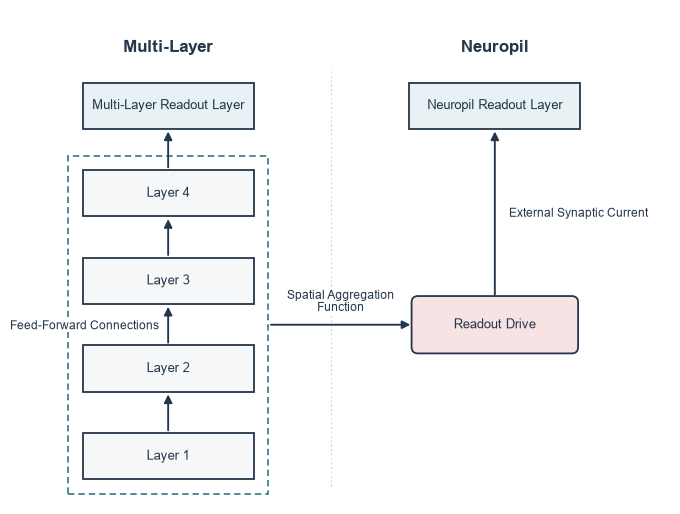

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrowPatch






INK = '#24364b'
ACCENT = '#2a7180'
PANEL_FILL = '#f5f7f9'
READOUT_FILL = '#e8f1f3'
DRIVE_FILL = '#f7e3e3'
DIVIDER = '#c8d0d7'






def draw_arrow(ax, start, end, label=None, label_offset=(0, 0)):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle='-|>',
        mutation_scale=12,
        linewidth=1.35,
        color=INK,
        shrinkA=2,
        shrinkB=2,
        zorder=2,
    )
    ax.add_patch(arrow)




    if label is not None:
        x_mid = 0.5 * (start[0] + end[0]) + label_offset[0]
        y_mid = 0.5 * (start[1] + end[1]) + label_offset[1]
        ax.text(
            x_mid,
            y_mid,
            label,
            ha='center',
            va='center',
            fontsize=8.5,
            color=INK,
            linespacing=1.0,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'pad': 1.5},
            zorder=4,
        )






def draw_box(
    ax,
    center_x,
    center_y,
    width,
    height,
    text,
    rounded=False,
    facecolor=PANEL_FILL,
    linewidth=1.3,
):
    x = center_x - width / 2
    y = center_y - height / 2




    if rounded:
        patch = FancyBboxPatch(
            (x, y),
            width,
            height,
            boxstyle='round,pad=0.02,rounding_size=0.08',
            linewidth=linewidth,
            facecolor=facecolor,
            edgecolor=INK,
            zorder=3,
        )
    else:
        patch = Rectangle(
            (x, y),
            width,
            height,
            linewidth=linewidth,
            facecolor=facecolor,
            edgecolor=INK,
            zorder=3,
        )




    ax.add_patch(patch)
    ax.text(
        center_x,
        center_y,
        text,
        ha='center',
        va='center',
        fontsize=9.5,
        color=INK,
        zorder=4,
    )




    return patch






fig, ax = plt.subplots(figsize=(7.3, 5.2), facecolor='white')
ax.set_xlim(0.45, 8.55)
ax.set_ylim(0.45, 6.65)
ax.set_aspect('equal', adjustable='box')
ax.axis('off')




left_x = 2.25
right_x = 6.35
box_w = 2.15
box_h = 0.58




layer_y = {
    'Layer 1': 1.05,
    'Layer 2': 2.15,
    'Layer 3': 3.25,
    'Layer 4': 4.35,
    'Multi-Layer Readout Layer': 5.45,
}




header_y = 6.18
ax.text(
    left_x,
    header_y,
    'Multi-Layer',
    ha='center',
    va='center',
    fontsize=12.5,
    fontweight='bold',
    color=INK,
)
ax.text(
    right_x,
    header_y,
    'Neuropil',
    ha='center',
    va='center',
    fontsize=12.5,
    fontweight='bold',
    color=INK,
)




for label, y in layer_y.items():
    draw_box(
        ax,
        center_x=left_x,
        center_y=y,
        width=box_w,
        height=box_h,
        text=label,
        facecolor=READOUT_FILL if label == 'Multi-Layer Readout Layer' else PANEL_FILL,
    )




layer_names = list(layer_y.keys())
for i in range(len(layer_names) - 1):
    lower = layer_names[i]
    upper = layer_names[i + 1]
    y0 = layer_y[lower] + box_h / 2
    y1 = layer_y[upper] - box_h / 2




    label = 'Feed-Forward Connections' if lower == 'Layer 2' else None
    offset = (-1.05, 0) if label else (0, 0)
    draw_arrow(
        ax,
        (left_x, y0),
        (left_x, y1),
        label=label,
        label_offset=offset,
    )




aggregation_margin = 0.18
aggregation_layers = ['Layer 1', 'Layer 2', 'Layer 3', 'Layer 4']
aggregation_y_min = min(layer_y[name] for name in aggregation_layers) - box_h / 2
aggregation_y_max = max(layer_y[name] for name in aggregation_layers) + box_h / 2
agg_x = left_x
agg_y = (aggregation_y_min + aggregation_y_max) / 2
agg_w = box_w + 2 * aggregation_margin
agg_h = aggregation_y_max - aggregation_y_min + 2 * aggregation_margin




aggregation_box = Rectangle(
    (agg_x - agg_w / 2, agg_y - agg_h / 2),
    agg_w,
    agg_h,
    linewidth=1.15,
    linestyle=(0, (4, 2.5)),
    facecolor='none',
    edgecolor=ACCENT,
    zorder=1,
)
ax.add_patch(aggregation_box)




neuropil_readout_y = 5.45
drive_y = agg_y
drive_w = 2.05
drive_h = 0.68




draw_box(
    ax,
    center_x=right_x,
    center_y=neuropil_readout_y,
    width=box_w,
    height=box_h,
    text='Neuropil Readout Layer',
    facecolor=READOUT_FILL,
)
draw_box(
    ax,
    center_x=right_x,
    center_y=drive_y,
    width=drive_w,
    height=drive_h,
    text='Readout Drive',
    rounded=True,
    facecolor=DRIVE_FILL,
)




draw_arrow(
    ax,
    (agg_x + agg_w / 2, agg_y),
    (right_x - drive_w / 2, agg_y),
    label='Spatial Aggregation\nFunction',
    label_offset=(0, 0.30),
)
draw_arrow(
    ax,
    (right_x, drive_y + drive_h / 2),
    (right_x, neuropil_readout_y - box_h / 2),
    label='External Synaptic Current',
    label_offset=(1.05, 0),
)




column_divider_x = (left_x + right_x) / 2
ax.plot(
    [column_divider_x, column_divider_x],
    [0.68, 5.92],
    linewidth=0.8,
    linestyle=(0, (1.5, 2.5)),
    color=DIVIDER,
    zorder=0,
)




fig.subplots_adjust(left=0.02, right=0.98, bottom=0.03, top=0.98)
fig.savefig('model_reduction_schematic.pdf', bbox_inches='tight', pad_inches=0.04)
fig.savefig(
    'model_reduction_schematic.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.04,
)
plt.show()

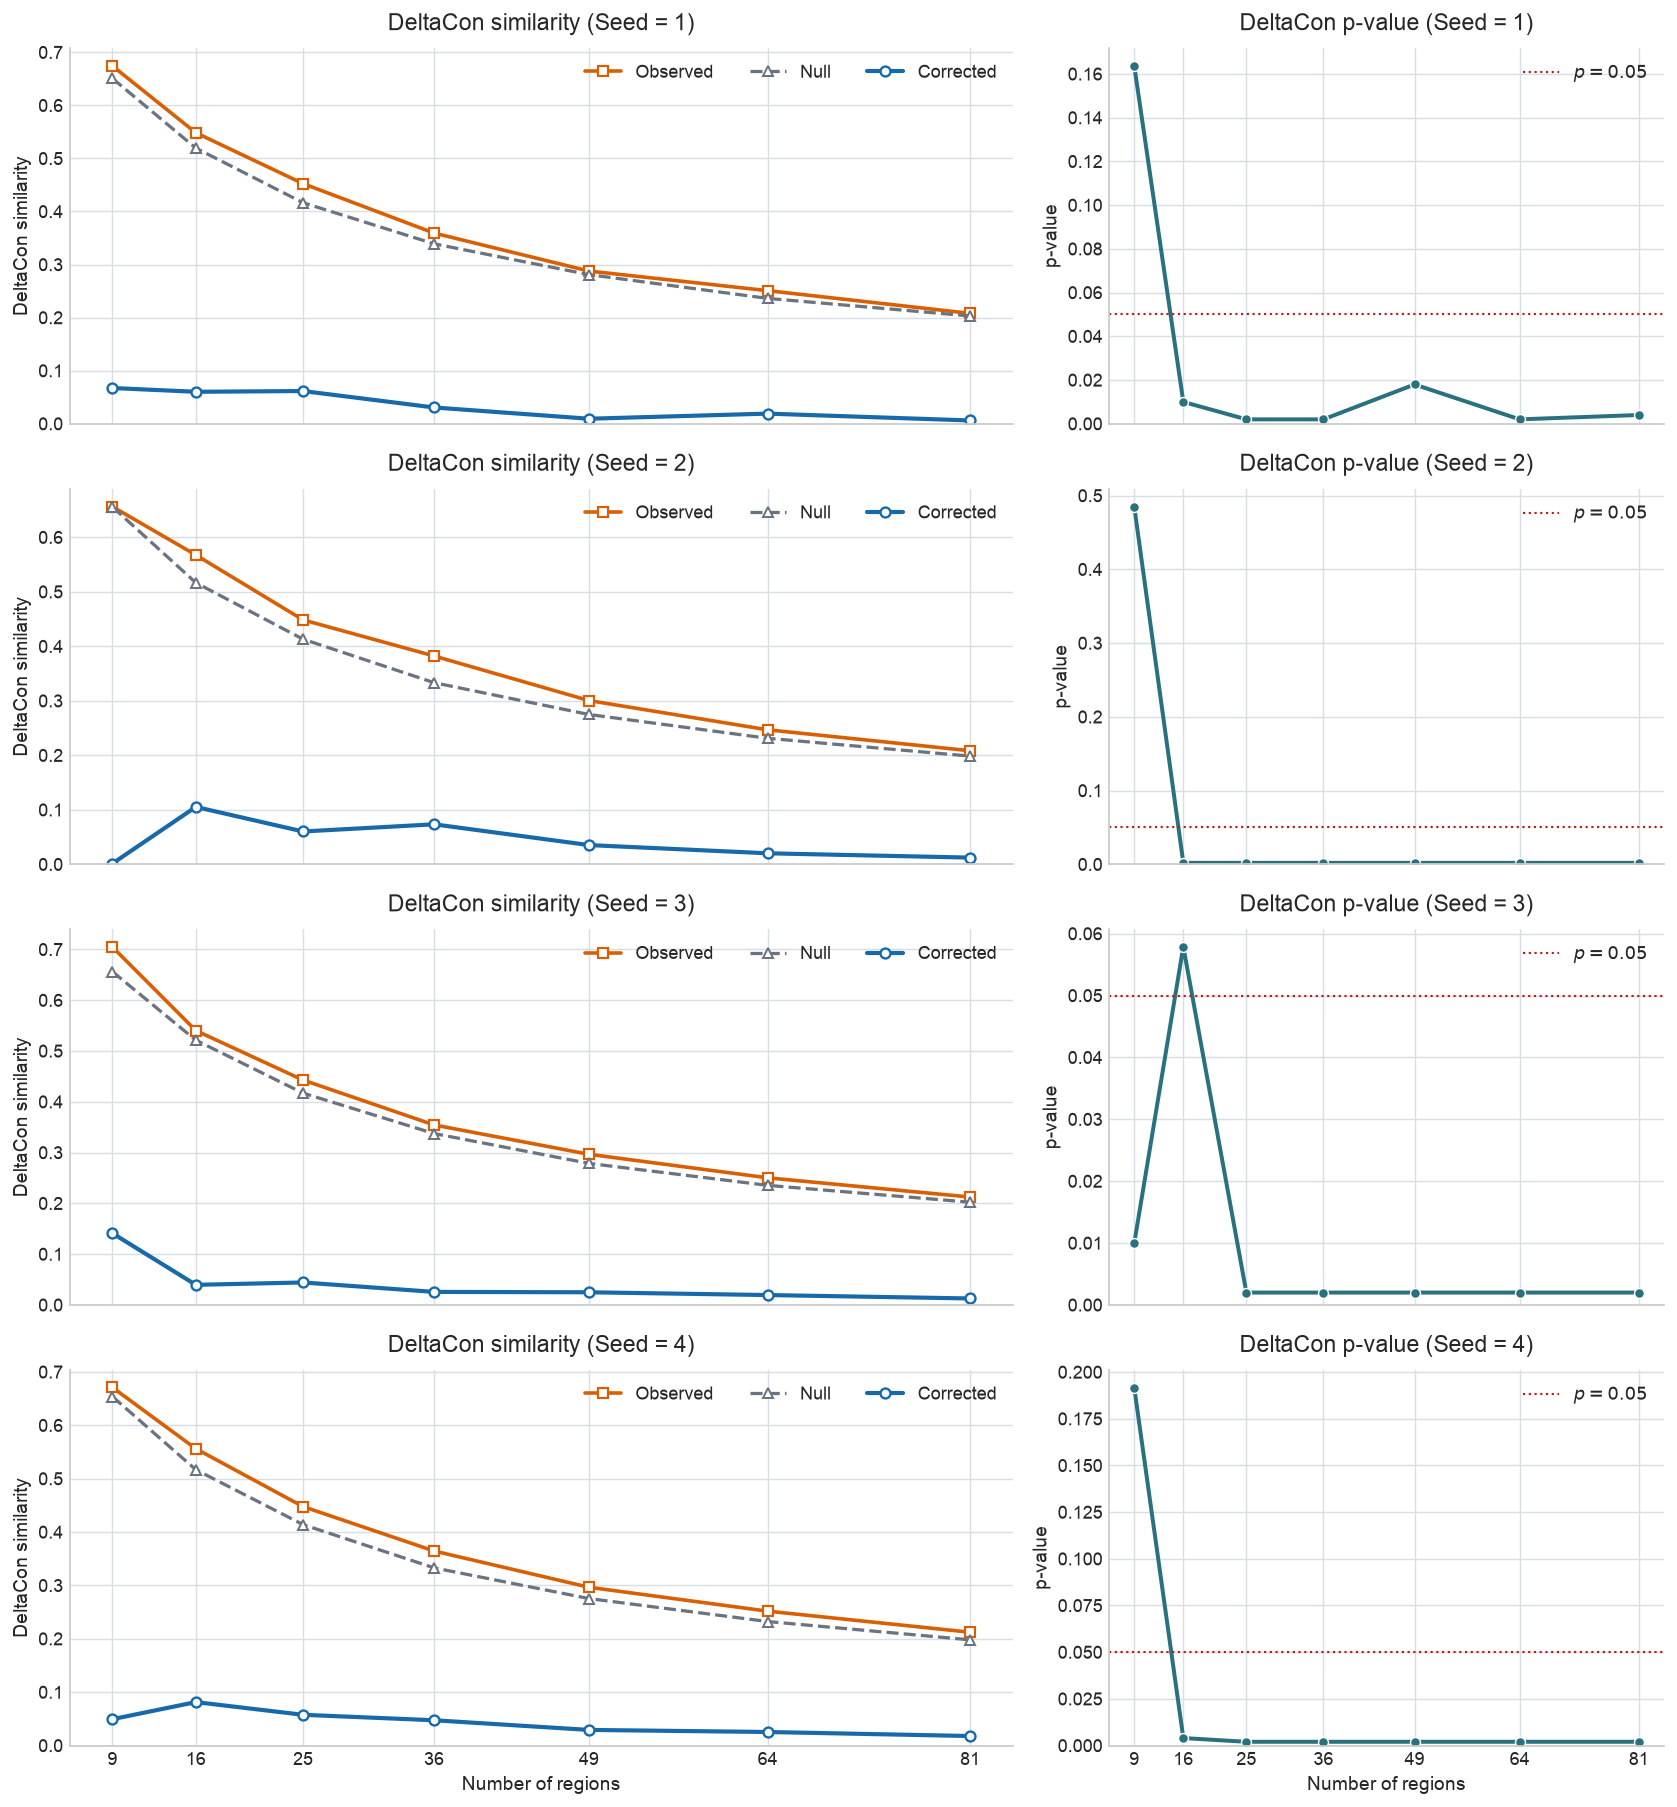

In [ ]:
import csv
from pathlib import Path


import matplotlib.pyplot as plt


csv_paths = [
    Path(f'output/figures/spatial_sweep/spatial_seed_{seed}.csv')
    for seed in range(1, 5)
]


plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(
    nrows=len(csv_paths),
    ncols=2,
    figsize=(13, 14),
    dpi=130,
    sharex='col',
    gridspec_kw={'width_ratios': [1.7, 1]},
)


for seed, (ax_metrics, ax_p, csv_path) in enumerate(
    zip(axes[:, 0], axes[:, 1], csv_paths),
    start=1,
):
    with csv_path.open(newline='') as f:
        rows = sorted(csv.DictReader(f), key=lambda row: int(row['n_regions']))


    n_regions = [int(row['n_regions']) for row in rows]
    observed = [float(row['deltacon_observed']) for row in rows]
    null = [float(row['deltacon_null']) for row in rows]
    corrected = [float(row['deltacon_corrected']) for row in rows]
    p_values = [float(row['deltacon_p']) for row in rows]


    ax_metrics.plot(
        n_regions,
        observed,
        color='#d95f02',
        linewidth=2.0,
        marker='s',
        markersize=5.5,
        markerfacecolor='white',
        markeredgewidth=1.2,
        label='Observed',
    )
    ax_metrics.plot(
        n_regions,
        null,
        color='#6b7280',
        linewidth=1.8,
        linestyle='--',
        marker='^',
        markersize=5,
        markerfacecolor='white',
        markeredgewidth=1.1,
        label='Null',
    )
    ax_metrics.plot(
        n_regions,
        corrected,
        color='#1769aa',
        linewidth=2.3,
        marker='o',
        markersize=5.5,
        markerfacecolor='#f7fbff',
        markeredgewidth=1.3,
        label='Corrected',
    )


    ax_p.plot(
        n_regions,
        p_values,
        color='#2a7180',
        linewidth=2.2,
        marker='o',
        markersize=5.5,
        markeredgecolor='white',
        markeredgewidth=0.8,
    )
    ax_p.axhline(
        0.05,
        color='#b91c1c',
        linewidth=1.2,
        linestyle=':',
        label=r'$p = 0.05$',
    )


    ax_metrics.set_title(f'DeltaCon similarity (Seed = {seed})', fontsize=13, pad=10)
    ax_p.set_title(f'DeltaCon p-value (Seed = {seed})', fontsize=13, pad=10)
    ax_metrics.set_ylabel('DeltaCon similarity', fontsize=10.5)
    ax_p.set_ylabel('p-value', fontsize=10.5)
    ax_metrics.set_ylim(bottom=0)
    ax_p.set_ylim(bottom=0)
    ax_metrics.legend(frameon=False, loc='best', ncols=3)
    ax_p.legend(frameon=False, loc='best')


    for ax in (ax_metrics, ax_p):
        ax.set_xticks(n_regions)
        ax.grid(True, color='#d9dee5', linewidth=0.8)
        ax.set_axisbelow(True)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)


axes[-1, 0].set_xlabel('Number of regions', fontsize=10.5)
axes[-1, 1].set_xlabel('Number of regions', fontsize=10.5)
fig.tight_layout()


figure_path = Path('deltacon_spatial_sweep_summary.png')
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()


### Computation Workflow Figure Generation

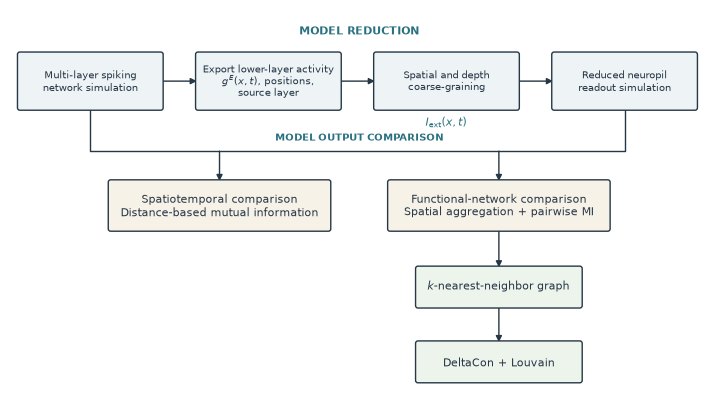

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


INK = '#263746'
ACCENT = '#2a7180'
SIMULATION_FILL = '#eef3f5'
ANALYSIS_FILL = '#f7f2e8'
RESULT_FILL = '#edf4ec'


def add_box(ax, center, width, height, text, facecolor, fontsize=8.0):
    x = center[0] - width / 2
    y = center[1] - height / 2
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle='round,pad=0.018,rounding_size=0.035',
        linewidth=1.0,
        edgecolor=INK,
        facecolor=facecolor,
        zorder=3,
    )
    ax.add_patch(box)
    ax.text(
        *center,
        text,
        ha='center',
        va='center',
        fontsize=fontsize,
        color=INK,
        linespacing=1.12,
        zorder=4,
    )


def add_arrow(ax, start, end):
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle='-|>',
            mutation_scale=9,
            linewidth=1.0,
            color=INK,
            shrinkA=0,
            shrinkB=0,
            zorder=2,
        )
    )


fig, ax = plt.subplots(figsize=(7.2, 4.15), facecolor='white')
ax.set_xlim(0, 10)
ax.set_ylim(0, 5.8)
ax.axis('off')

pipeline_y = 4.75
pipeline_x = [1.15, 3.7, 6.25, 8.8]
pipeline_width = 2.05
pipeline_height = 0.82
pipeline_text = [
    'Multi-layer spiking\nnetwork simulation',
    'Export lower-layer activity\n$g^E(x,t)$, positions,\nsource layer',
    'Spatial and depth\ncoarse-graining',
    'Reduced neuropil\nreadout simulation',
]

for x, text in zip(pipeline_x, pipeline_text):
    add_box(
        ax,
        (x, pipeline_y),
        width=pipeline_width,
        height=pipeline_height,
        text=text,
        facecolor=SIMULATION_FILL,
        fontsize=7.5,
    )

for left_x, right_x in zip(pipeline_x[:-1], pipeline_x[1:]):
    add_arrow(
        ax,
        (left_x + pipeline_width / 2, pipeline_y),
        (right_x - pipeline_width / 2, pipeline_y),
    )

ax.text(
    5.0,
    5.48,
    'MODEL REDUCTION',
    ha='center',
    va='center',
    fontsize=8,
    fontweight='bold',
    color=ACCENT,
)

# A shared bus keeps the two model-output comparisons explicit and uncluttered.
bus_y = 3.72
pipeline_bottom = pipeline_y - pipeline_height / 2
ax.plot(
    [pipeline_x[0], pipeline_x[0], pipeline_x[-1], pipeline_x[-1]],
    [pipeline_bottom, bus_y, bus_y, pipeline_bottom],
    color=INK,
    linewidth=1.0,
    zorder=1,
)
ax.text(
    5.0,
    bus_y + 0.12,
    'MODEL OUTPUT COMPARISON',
    ha='center',
    va='bottom',
    fontsize=7.2,
    fontweight='bold',
    color=ACCENT,
)

comparison_y = 2.92
comparison_width = 3.15
comparison_height = 0.72
left_center = (3.0, comparison_y)
right_center = (7.0, comparison_y)

add_arrow(ax, (left_center[0], bus_y), (left_center[0], comparison_y + comparison_height / 2))
add_arrow(ax, (right_center[0], bus_y), (right_center[0], comparison_y + comparison_height / 2))

add_box(
    ax,
    left_center,
    width=comparison_width,
    height=comparison_height,
    text='Spatiotemporal comparison\nDistance-based mutual information',
    facecolor=ANALYSIS_FILL,
    fontsize=8.0,
)
add_box(
    ax,
    right_center,
    width=comparison_width,
    height=comparison_height,
    text='Functional-network comparison\nSpatial aggregation + pairwise MI',
    facecolor=ANALYSIS_FILL,
    fontsize=8.0,
)

# Functional-network products are vertically ordered to show their dependency.
product_width = 2.35
product_height = 0.58
knn_center = (right_center[0], 1.72)
deltacon_center = (right_center[0], 0.62)

add_arrow(
    ax,
    (right_center[0], comparison_y - comparison_height / 2),
    (knn_center[0], knn_center[1] + product_height / 2),
)
add_box(
    ax,
    knn_center,
    width=product_width,
    height=product_height,
    text=r'$k$-nearest-neighbor graph',
    facecolor=RESULT_FILL,
    fontsize=8.0,
)
add_arrow(
    ax,
    (knn_center[0], knn_center[1] - product_height / 2),
    (deltacon_center[0], deltacon_center[1] + product_height / 2),
)
add_box(
    ax,
    deltacon_center,
    width=product_width,
    height=product_height,
    text='DeltaCon + Louvain',
    facecolor=RESULT_FILL,
    fontsize=8.0,
)

fig.subplots_adjust(left=0.015, right=0.985, bottom=0.025, top=0.975)
fig.savefig('computational_workflow.pdf', bbox_inches='tight', pad_inches=0.04)
fig.savefig(
    'computational_workflow.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.04,
)
plt.show()
